# 🐾 Pipeline BCS en cascade — Présentation

Ce notebook présente, de bout en bout, la **cascade de détermination du *Body Condition Score* (BCS)** entraînée par `scripts/run_cascade_trainings.sh`.

La cascade enchaîne quatre modèles, chacun conditionnant le suivant :

| Étape | Modèle | Rôle | Données |
|-------|--------|------|---------|
| 1. **Espèce** | ViT (2 classes) | chien vs chat | Stanford Dogs + Oxford-IIIT |
| 2. **Race** | ViT (120 / 12 classes) | race, *routée par l'espèce* | Stanford (chien) / Oxford (chat) |
| 3. **Segmentation** | DeepLabV3 / SAM 2 / SAM 3 | silhouette de l'animal | — |
| 4. **BCS** | ViT + têtes MLP (LOCO-CV) | score 1–9, *routé par l'espèce* | Cats_OGR_dataset |

> **Routage** : la sortie « espèce » sélectionne le classifieur de race **et** le régresseur BCS. La segmentation isole la silhouette transmise au régresseur BCS. Le modèle BCS chien reste un *placeholder* (aucune donnée chien à ce jour).

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")

# Racine du dépôt (le notebook vit dans notebooks/)
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
%cd {REPO}

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Repo   :", REPO)
print("Device :", DEVICE)

/home/SPeillet/bcs_determination


Repo   : /home/SPeillet/bcs_determination
Device : cuda


## 1. Modèles entraînés et points de contrôle

`app_checkpoints` résout automatiquement les checkpoints publiés par la cascade. On affiche les modèles actifs et on vérifie leur disponibilité.

In [2]:
from bcs_pipeline.app_checkpoints import (
    describe_active_models, bcs_available,
    species_available, dog_breed_available, cat_breed_available,
    resolve_species_ckpt, resolve_dog_breed_ckpt, resolve_cat_breed_ckpt,
)

print(describe_active_models())
print()
rows = [
    ("species",   species_available(),   resolve_species_ckpt()),
    ("dog_breed", dog_breed_available(), resolve_dog_breed_ckpt()),
    ("cat_breed", cat_breed_available(), resolve_cat_breed_ckpt()),
    ("bcs_cat",   bcs_available("cat"),  "checkpoints/bcs_regression/cat"),
    ("bcs_dog",   bcs_available("dog"),  None),
]
print(f"{'étape':10s} {'dispo':6s} chemin")
for name, avail, path in rows:
    mark = "✔" if avail else "—"
    print(f"{name:10s} {mark:6s} {path if path else '(placeholder)'}")

Active models:
  classification : vit (132 classes) ← checkpoints/classification/vit_dogs_cats/last.ckpt
  segmentation   : DeepLabV3 ← checkpoints/segmentation/deeplabv3_resnet50_last-v1.ckpt
  segmentation   : SAM 2.1   ← checkpoints/segmentation/sam2.1_hiera_large.pt
  segmentation   : SAM 3     ← checkpoints/segmentation/sam3/sam3.pt
  pose           : YOLO      ← checkpoints/pose/yolo_best.pt
  bcs regression : ViT+MLP   ← checkpoints/bcs_regression

étape      dispo  chemin
species    ✔      /home/SPeillet/bcs_determination/checkpoints/classification/species/last.ckpt
dog_breed  ✔      /home/SPeillet/bcs_determination/checkpoints/classification/dog_breed/last.ckpt
cat_breed  ✔      /home/SPeillet/bcs_determination/checkpoints/classification/cat_breed/last.ckpt
bcs_cat    ✔      checkpoints/bcs_regression/cat
bcs_dog    —      (placeholder)


## 2. Inférence en cascade sur des images d'exemple

`run_full_inference` exécute toute la cascade en un appel : espèce → race (routée) → segmentation (DeepLabV3) → BCS (routé, sur la silhouette segmentée). Elle produit aussi une visualisation combinée.

In [3]:
import glob
from bcs_pipeline.inference import run_full_inference

SEG_CKPT = sorted(glob.glob("checkpoints/segmentation/deeplab*"))[0]
OUT_DIR = Path("notebooks/_presentation_outputs"); OUT_DIR.mkdir(exist_ok=True)

SAMPLES = [
    ("Chat — Bengal", "data/Oxford-IIIT_pet_dataset/images/Bengal_162.jpg"),
    ("Chien — Curly Coated Retriever",
     "data/Stanford_dogs/Images/n02099429-curly-coated_retriever/n02099429_2934.jpg"),
]

def run_cascade(image_path, tag):
    out = OUT_DIR / f"{tag}.png"
    return run_full_inference(
        image_path,
        species_ckpt=str(resolve_species_ckpt()), species_model_name="vit",
        dog_breed_ckpt=str(resolve_dog_breed_ckpt()),
        cat_breed_ckpt=str(resolve_cat_breed_ckpt()),
        stanford_data_dir="data/Stanford_dogs",
        oxford_data_dir="data/Oxford-IIIT_pet_dataset",
        classification_model_name="vit",
        segmentation_ckpt=SEG_CKPT, segmentation_backend="deeplab",
        bcs_ckpt="checkpoints/bcs_regression",
        output_path=str(out), device=DEVICE,
    )

results = []
for i, (title, path) in enumerate(SAMPLES):
    res = run_cascade(path, f"sample_{i}")
    results.append((title, path, res))
    sp = res["species"]["species"] if res.get("species") else "?"
    breed = res["classification"]["class_name"] if res.get("classification") else "?"
    bcs = res.get("bcs") or {}
    bcs_txt = f"{bcs.get('bcs')} ({bcs.get('category')})" if bcs.get("bcs") else "n/a (chien)"
    print(f"{title}\n   espèce={sp}  race={breed}  BCS={bcs_txt}\n")

Chat — Bengal
   espèce=cat  race=Egyptian Mau  BCS=4.82 (Idéal)



Chien — Curly Coated Retriever
   espèce=dog  race=Curly Coated Retriever  BCS=n/a (chien)



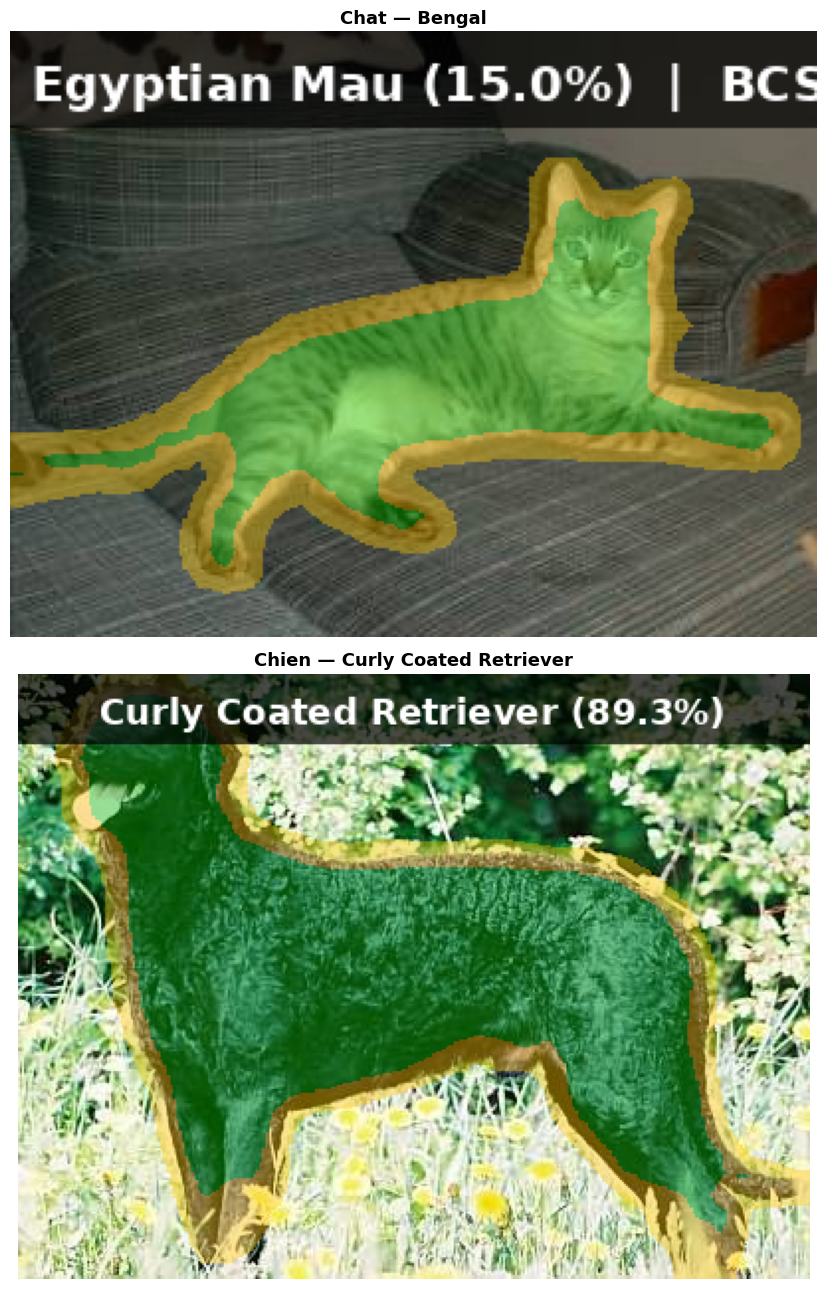

In [4]:
# Visualisations combinées (image + race + masque + BCS)
fig, axes = plt.subplots(len(results), 1, figsize=(13, 6.5 * len(results)))
if len(results) == 1:
    axes = [axes]
for ax, (title, _, res) in zip(axes, results):
    ax.imshow(Image.open(res["output_path"]))
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Évaluation du régresseur BCS (validation croisée LOCO)

Le modèle BCS chat est évalué en **Leave-One-Cat-Out** (LOCO-CV) : pour chacun des 11 chats du `Cats_OGR_dataset`, on entraîne sur les 10 autres et on prédit le chat laissé de côté. Cela mesure la généralisation à un animal jamais vu. Les prédictions sont stockées dans `checkpoints/bcs_regression/cat/predictions.json`.

In [5]:
pred = json.load(open("checkpoints/bcs_regression/cat/predictions.json"))
m = pred["metrics"]
cfg = pred["config"]
print(f"Folds (chats)     : {len(pred['folds'])}")
print(f"Prédictions       : {len(pred['predictions'])}")
print(f"Hyperparamètres   : epochs={cfg['max_epochs']}, lr={cfg['lr']}, hidden={cfg['hidden_dim']}, dropout={cfg['dropout']}")
print()
print(f"  MAE  = {m['mae']:.3f}  (erreur absolue moyenne, en points de BCS)")
print(f"  RMSE = {m['rmse']:.3f}")
print(f"  MSE  = {m['mse']:.3f}")

Folds (chats)     : 11
Prédictions       : 22
Hyperparamètres   : epochs=80, lr=0.001, hidden=128, dropout=0.3

  MAE  = 0.821  (erreur absolue moyenne, en points de BCS)
  RMSE = 0.923
  MSE  = 0.853


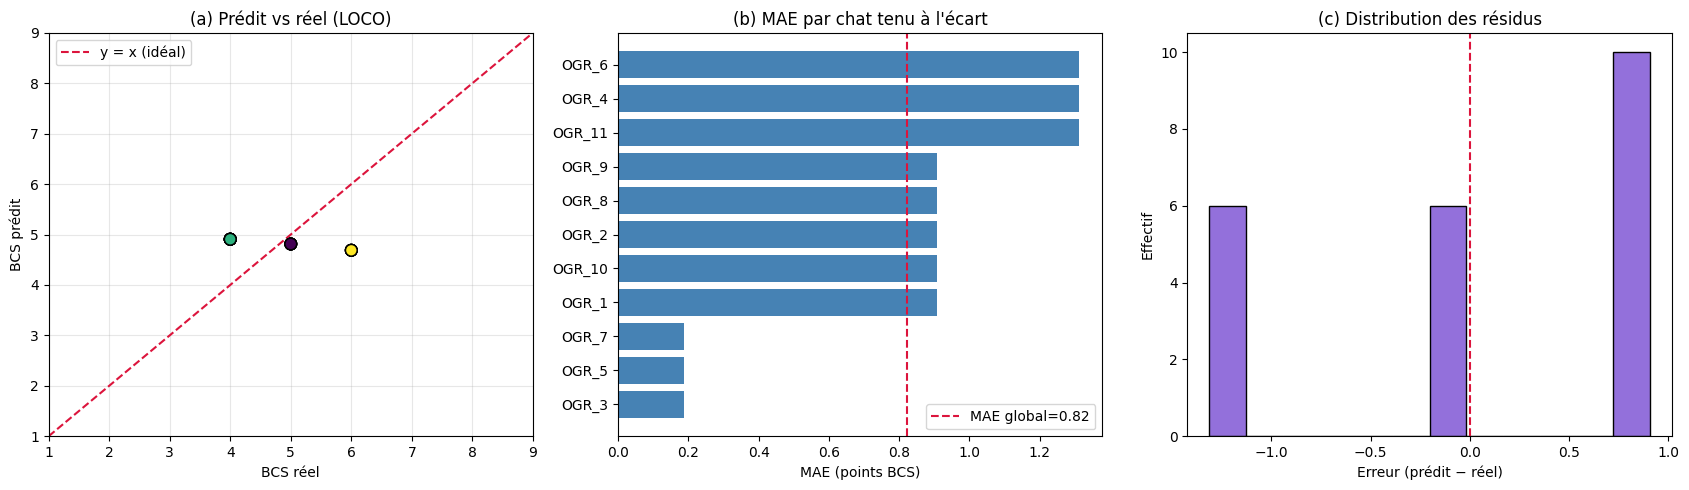

In [6]:
P = pred["predictions"]
actual = np.array([p["BCS_actual"] for p in P])
predicted = np.array([p["BCS_predicted"] for p in P])
abs_err = np.abs(actual - predicted)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

# (a) Prédit vs réel
ax1.scatter(actual, predicted, c=abs_err, cmap="viridis", s=70, edgecolor="k", zorder=3)
lims = [1, 9]
ax1.plot(lims, lims, "--", color="crimson", label="y = x (idéal)")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("BCS réel"); ax1.set_ylabel("BCS prédit")
ax1.set_title("(a) Prédit vs réel (LOCO)"); ax1.legend(); ax1.grid(alpha=0.3)

# (b) MAE par chat (fold)
fold_ids, fold_mae = [], []
for f in pred["folds"]:
    fp = f["predictions"]
    e = np.mean([abs(q["BCS_actual"] - q["BCS_predicted"]) for q in fp])
    fold_ids.append(f.get("fold_cat", f.get("hold_out", "?")))
    fold_mae.append(e)
order = np.argsort(fold_mae)
ax2.barh(np.array(fold_ids)[order], np.array(fold_mae)[order], color="steelblue")
ax2.axvline(m["mae"], color="crimson", ls="--", label=f"MAE global={m['mae']:.2f}")
ax2.set_xlabel("MAE (points BCS)"); ax2.set_title("(b) MAE par chat tenu à l'écart")
ax2.legend()

# (c) Distribution des erreurs
ax3.hist(predicted - actual, bins=12, color="mediumpurple", edgecolor="k")
ax3.axvline(0, color="crimson", ls="--")
ax3.set_xlabel("Erreur (prédit − réel)"); ax3.set_ylabel("Effectif")
ax3.set_title("(c) Distribution des résidus")

plt.tight_layout(); plt.show()

## 4. Conclusion

- ✅ **Cascade complète et fonctionnelle** : les 4 étapes (espèce → race → segmentation → BCS) s'enchaînent et tous les checkpoints sont résolus.
- ✅ **Routage par espèce** opérationnel : un chat est dirigé vers le classifieur de race chat **et** le régresseur BCS chat ; un chien vers le classifieur chien (BCS chien = *placeholder*).
- ✅ **BCS chat** : MAE ≈ **0,82 point** en validation LOCO (généralisation à un chat inédit), score borné à l'échelle WSAVA 1–9.

**Pistes** : collecter des données chien pour lever le *placeholder* BCS chien ; comparer les *backends* de segmentation (DeepLabV3 vs SAM 2 / SAM 3) sur la qualité de silhouette transmise au régresseur.